# Experimento 1: Resta de la Temperatura del Sustrato (Escala de Grises - Minuto a Minuto)
Este notebook muestra cómo restar la firma térmica (matriz de temperatura) de la superficie (madera/vidrio) antes del contacto para resaltar únicamente el calor de la huella dactilar/mano.

Mostramos los resultados en **escala de grises** minuto a minuto desde el segundo 1 hasta el 601 (10 minutos).

Haremos dos pruebas con el sujeto **Juandiego** (ambas secuencias completas de 47 fotogramas):
1. **Con secuencia pre-mano (`test_pre_mano`):** Utilizando la secuencia de `juandiego` en **madera** (`jua_woo_test1`), donde hay grabaciones previas al contacto.
2. **Sin secuencia pre-mano (Fallback):** Utilizando la secuencia de `juandiego` en **vidrio** (`jua_gla_test1`) donde no hay registro pre-mano y usamos el último fotograma ($t=601\text{s}$) de la secuencia como línea base.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Bibliotecas importadas con éxito.")

Bibliotecas importadas con éxito.


## 1. Cargar metadatos y buscar secuencias de Juan Diego en Madera y Vidrio
Cargamos `metadata_full.csv` para filtrar las secuencias correspondientes.

In [7]:
metadata_path = Path("../processed_data/metadata_full.csv")
if not metadata_path.exists():
    # Intentamos desde el directorio raíz si el notebook se ejecuta en la raíz
    metadata_path = Path("processed_data/metadata_full.csv")

df = pd.read_csv(metadata_path)
jd_wood = df[(df["name"] == "juandiego") & (df["surface"] == "wood")].sort_values(["sequence_id", "t_seconds"])
print(f"Total filas para Juan Diego en madera: {len(jd_wood)}")
print("Secuencias de madera encontradas:", jd_wood["sequence_id"].unique())

jd_glass = df[(df["name"] == "juandiego") & (df["surface"] == "glass")].sort_values(["sequence_id", "t_seconds"])
print(f"Total filas para Juan Diego en vidrio: {len(jd_glass)}")
print("Secuencias de vidrio encontradas:", jd_glass["sequence_id"].unique())

Total filas para Juan Diego en madera: 216
Secuencias de madera encontradas: <StringArray>
['jua_woo_test1', 'jua_woo_test2', 'jua_woo_test3']
Length: 3, dtype: str
Total filas para Juan Diego en vidrio: 139
Secuencias de vidrio encontradas: <StringArray>
['jua_gla_test1', 'jua_gla_test2', 'jua_gla_test3']
Length: 3, dtype: str


## 2. Calcular la Matriz de Temperatura del Material (Sustrato - Madera)
Para la secuencia `jua_woo_test1`, los fotogramas con `t_seconds < 0` (snapshots 1 a 25) corresponden al periodo antes del contacto (pre-mano). 
Promediaremos estas matrices térmicas para obtener una imagen limpia y libre de ruido de la madera sola.

In [8]:
seq_id = "jua_woo_test1"
seq_df = jd_wood[jd_wood["sequence_id"] == seq_id].sort_values("t_seconds")

# Filtrar pre-mano (t_seconds < 0)
pre_hand_df = seq_df[seq_df["t_seconds"] < 0]
print(f"Fotogramas pre-mano encontrados: {len(pre_hand_df)}")

# Cargar y promediar matrices térmicas pre-mano
root_dir = metadata_path.parent
pre_matrices = []
for _, row in pre_hand_df.iterrows():
    path = root_dir / row["thermal_path"]
    pre_matrices.append(np.load(path))

T_material = np.mean(pre_matrices, axis=0)
print(f"Matriz del material calculada. Forma: {T_material.shape} | Temp media: {T_material.mean():.2f}°C")

Fotogramas pre-mano encontrados: 25
Matriz del material calculada. Forma: (399, 354) | Temp media: 23.00°C


## 3. Comparar sustracción de Escalar vs. sustracción de Matriz minuto a minuto (Madera)
Recorremos la secuencia minuto a minuto (tiempos objetivos: 1s, 61s, 121s, 181s, 241s, 301s, 361s, 421s, 481s, 541s, 601s) en **escala de grises**.
Esto nos permite ver visualmente cómo decae el calor de la huella en la madera.

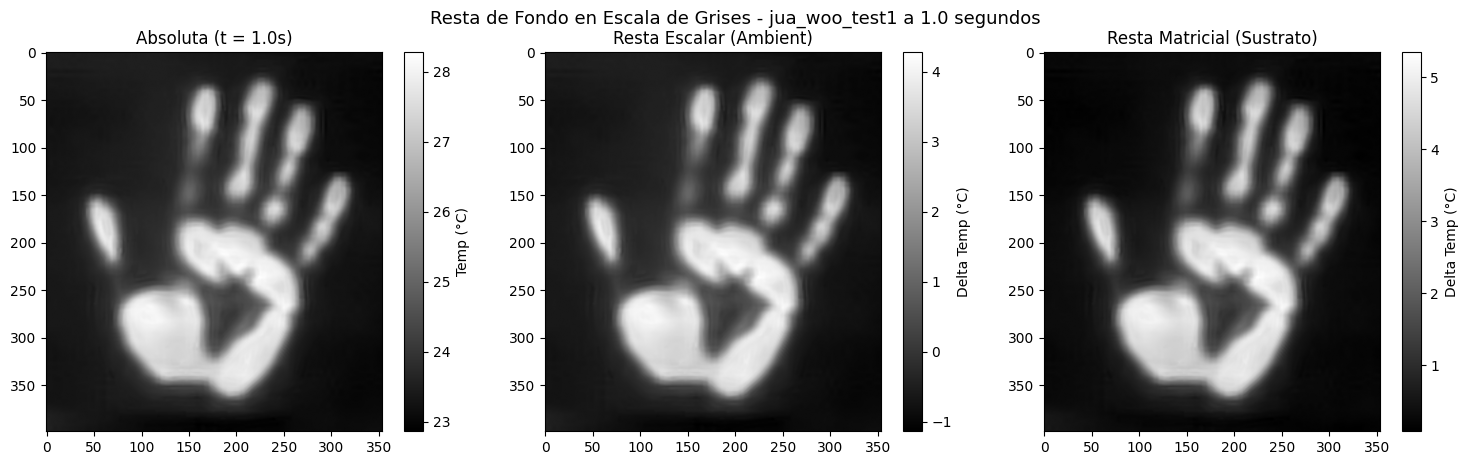

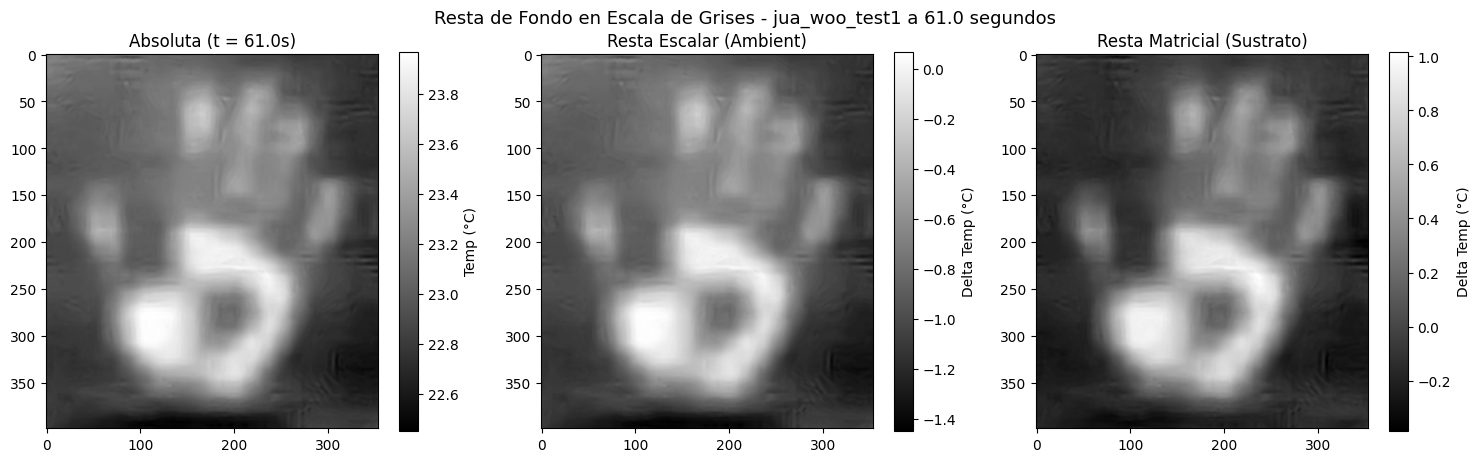

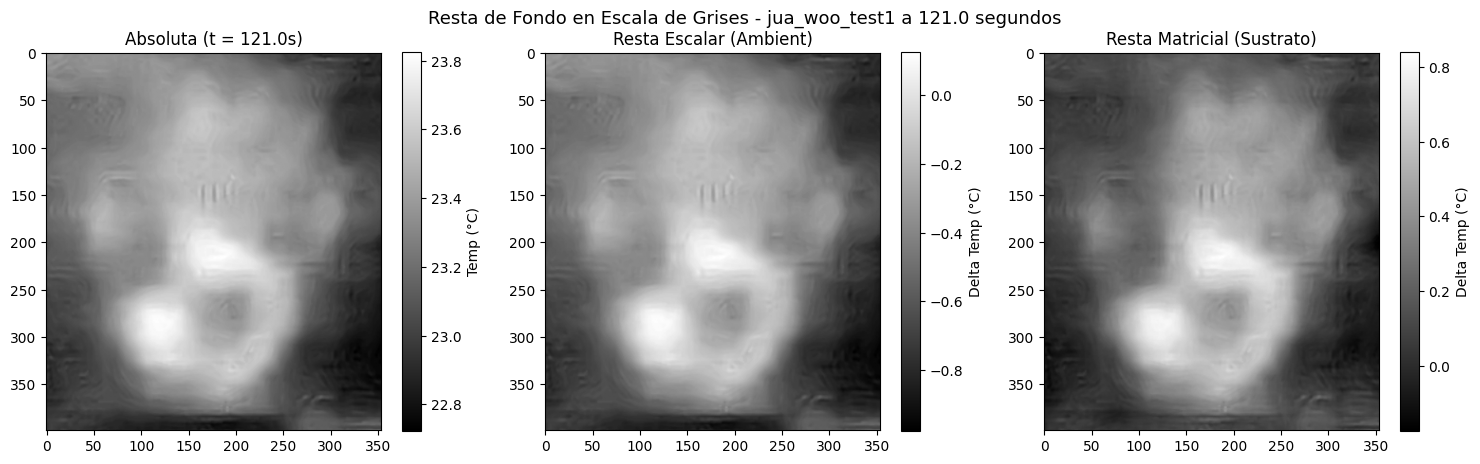

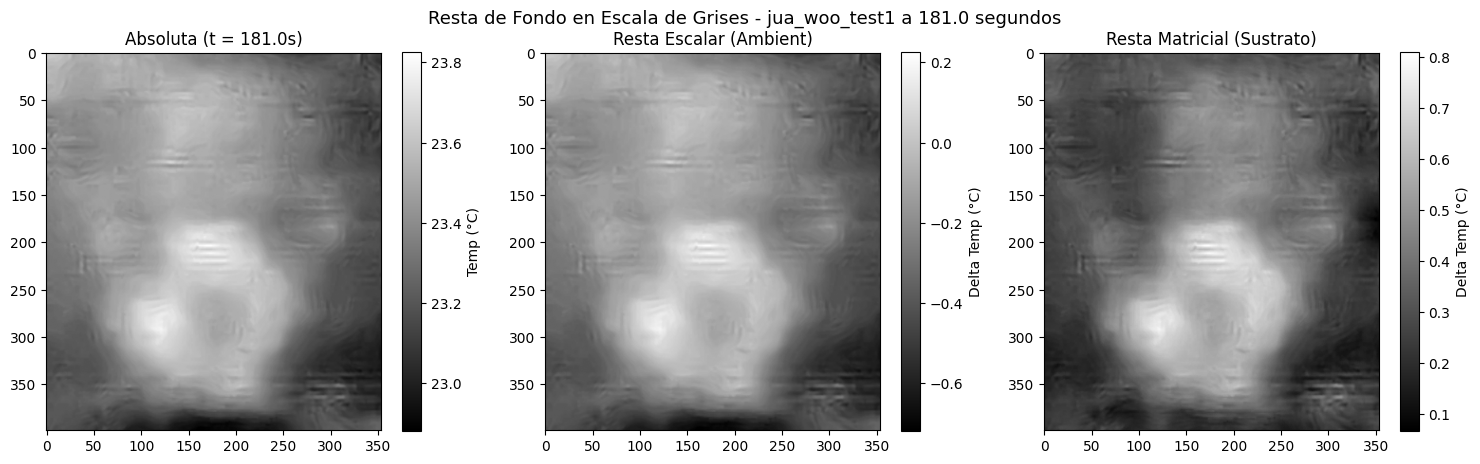

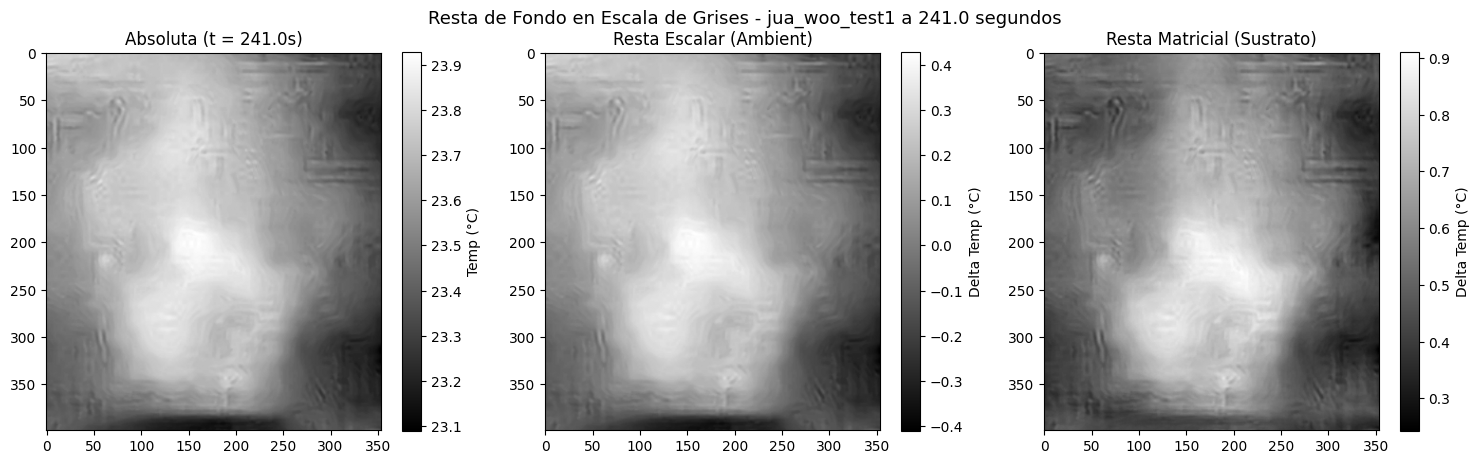

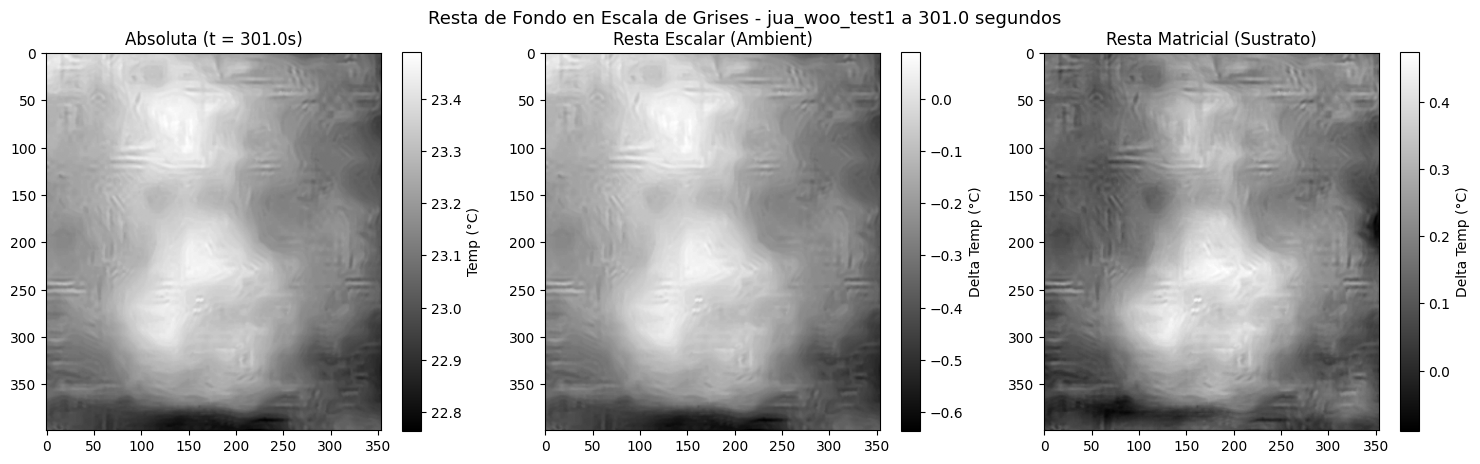

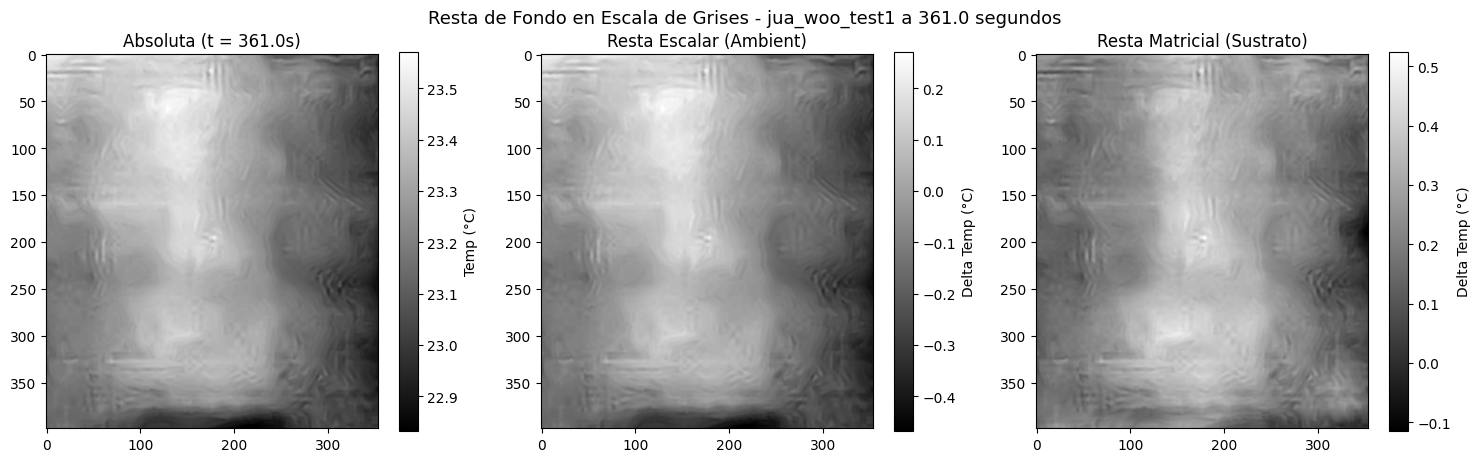

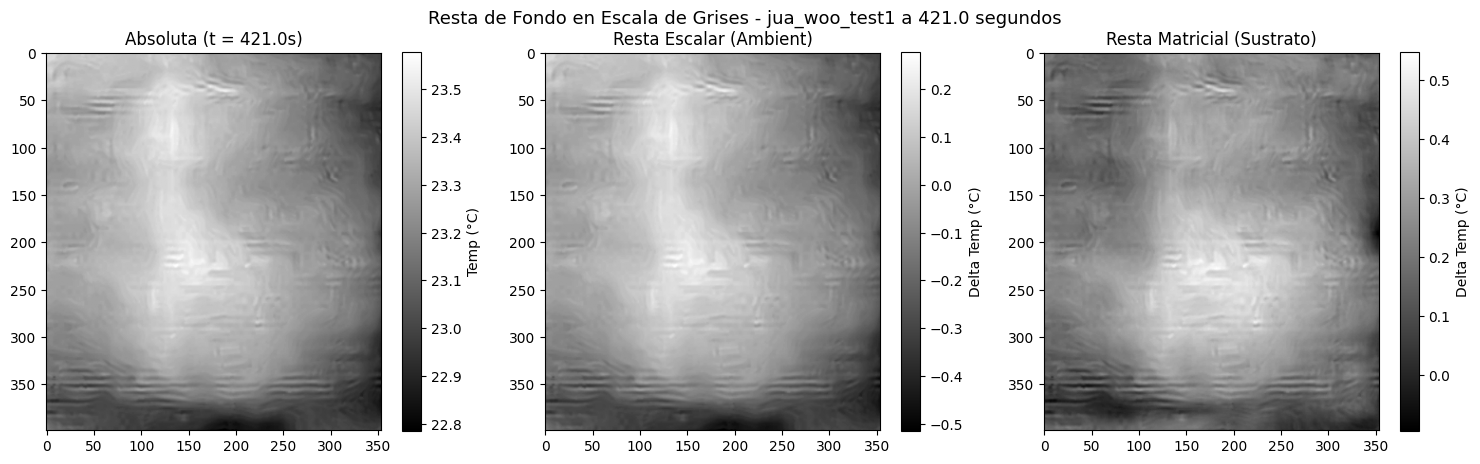

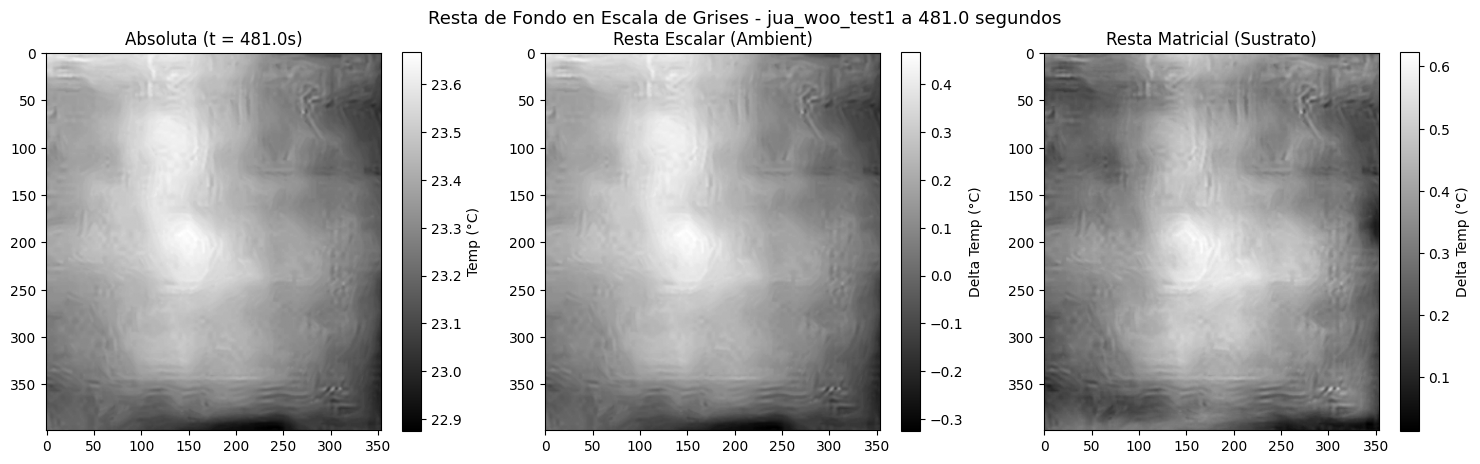

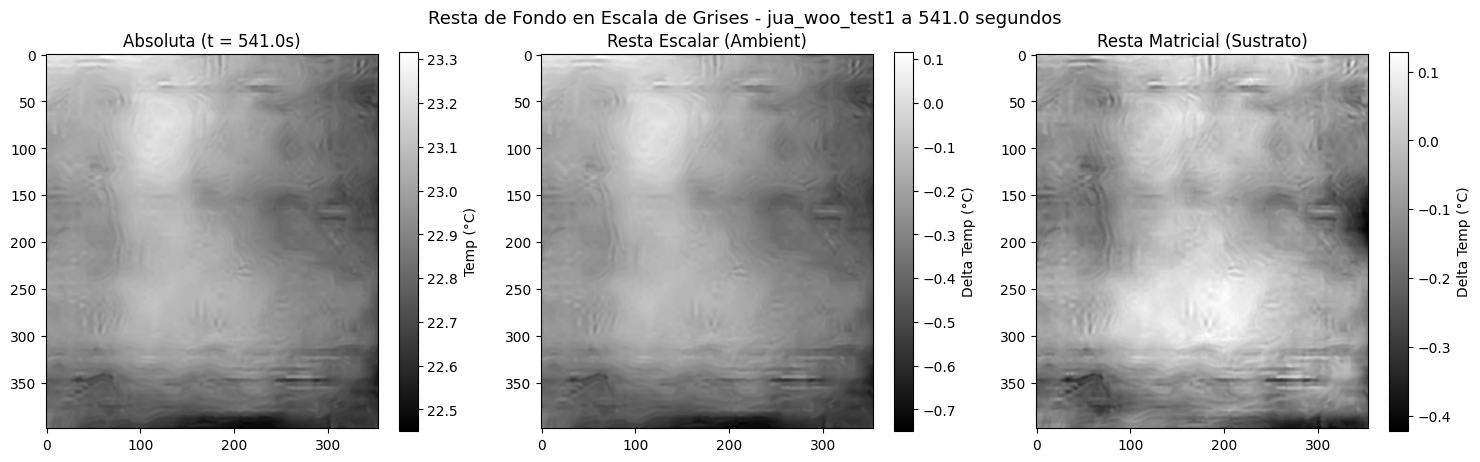

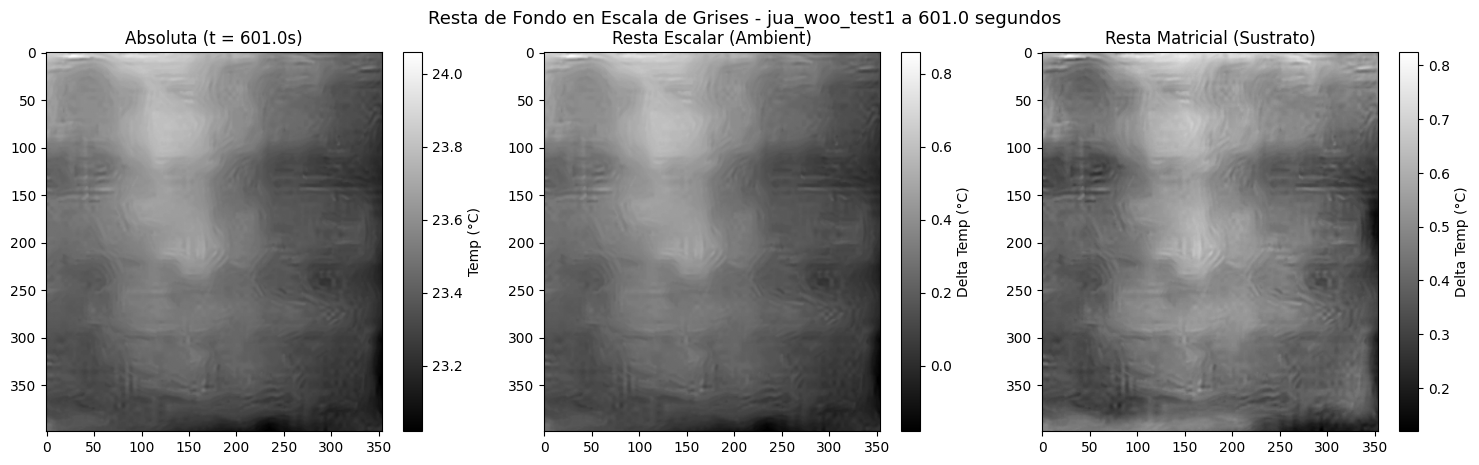

In [9]:
# Seleccionar snapshots post-mano
post_hand_df = seq_df[seq_df["t_seconds"] > 0]

target_times = [1.0, 61.0, 121.0, 181.0, 241.0, 301.0, 361.0, 421.0, 481.0, 541.0, 601.0]

for t_target in target_times:
    # Buscar el más cercano a t_target
    row = post_hand_df.iloc[(post_hand_df["t_seconds"] - t_target).abs().argsort()[:1]].iloc[0]
    
    path = root_dir / row["thermal_path"]
    T_post = np.load(path)
    
    # Método 1: Restar escalar (temperatura ambiente)
    ambient_temp = row["ambient_temp_C"]
    T_diff_scalar = T_post - ambient_temp
    
    # Método 2: Restar matriz del material
    T_diff_matrix = T_post - T_material
    
    # Graficar en escala de grises
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    
    # Absoluta
    im0 = axes[0].imshow(T_post, cmap='gray')
    axes[0].set_title(f"Absoluta (t = {row['t_seconds']:.1f}s)")
    fig.colorbar(im0, ax=axes[0], label='Temp (°C)')
    
    # Diferencial Escalar
    im1 = axes[1].imshow(T_diff_scalar, cmap='gray')
    axes[1].set_title("Resta Escalar (Ambient)")
    fig.colorbar(im1, ax=axes[1], label='Delta Temp (°C)')
    
    # Diferencial Matricial
    im2 = axes[2].imshow(T_diff_matrix, cmap='gray')
    axes[2].set_title("Resta Matricial (Sustrato)")
    fig.colorbar(im2, ax=axes[2], label='Delta Temp (°C)')
    
    plt.suptitle(f"Resta de Fondo en Escala de Grises - {seq_id} a {row['t_seconds']:.1f} segundos", fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Método Alternativo (Fallback) para Secuencias sin Pre-Mano minuto a minuto (Vidrio)
Para secuencias donde no hay carpeta pre-mano, como **Juandiego en Vidrio** (`jua_gla_test1`), usaremos el último fotograma ($t=601\text{s}$) de la misma secuencia como aproximación en escala de grises minuto a minuto.

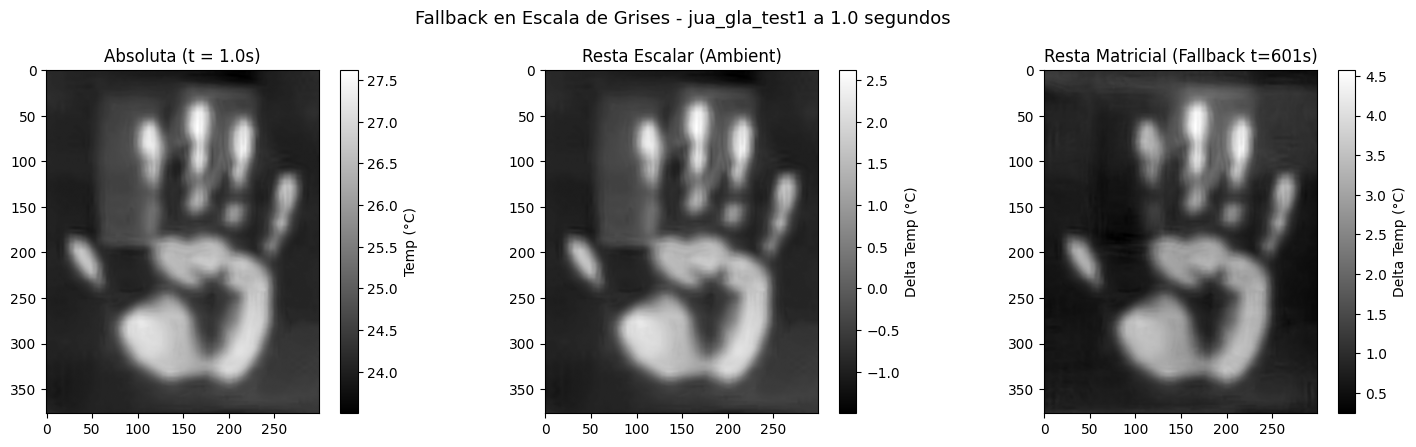

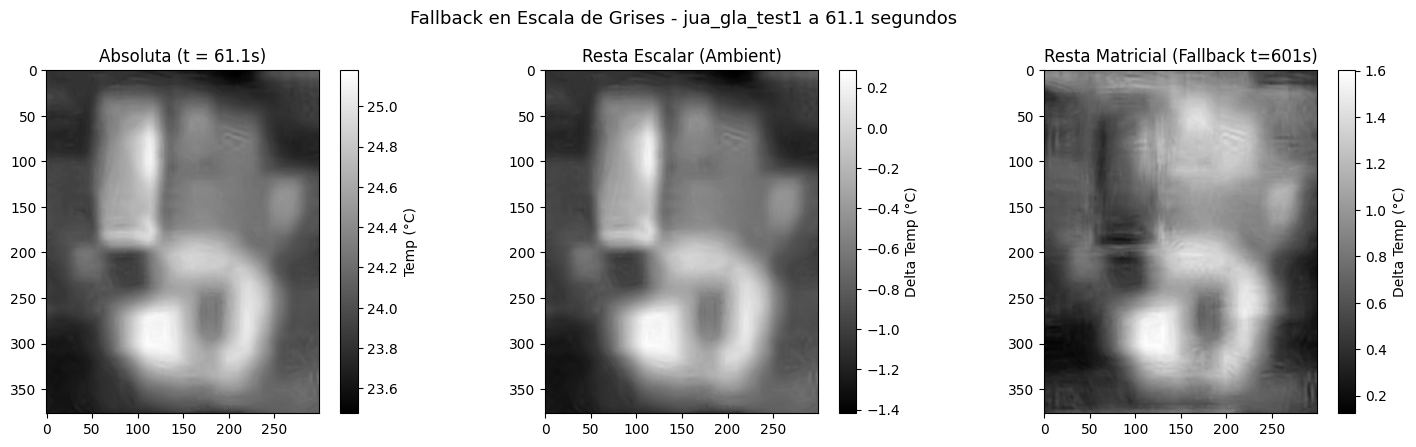

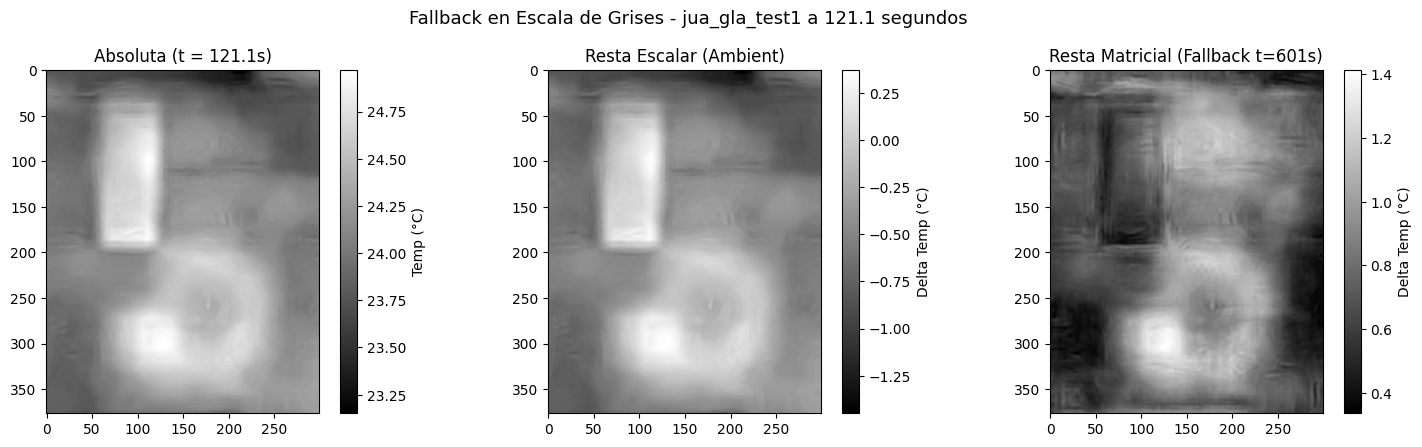

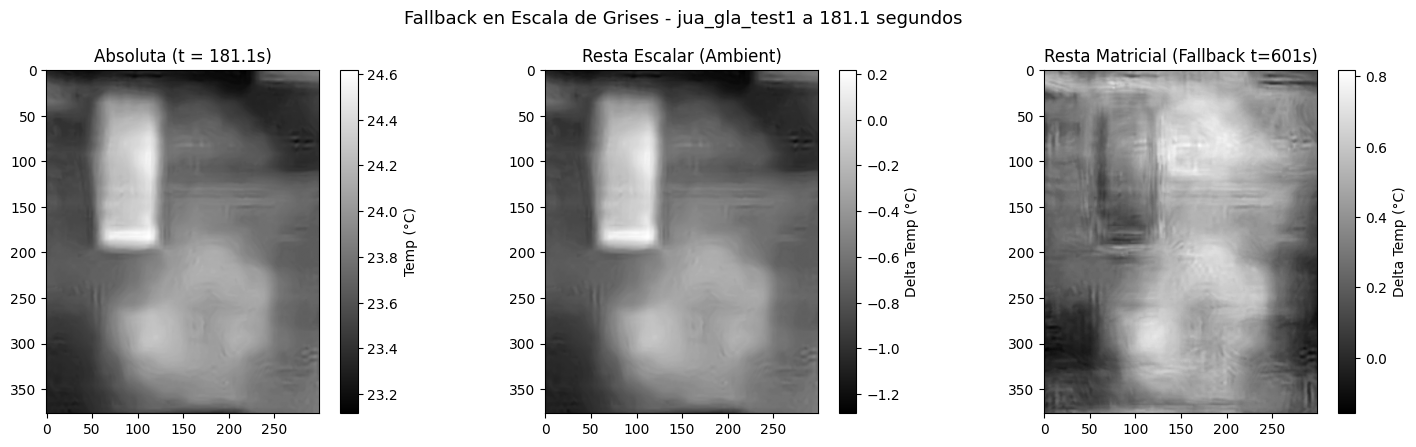

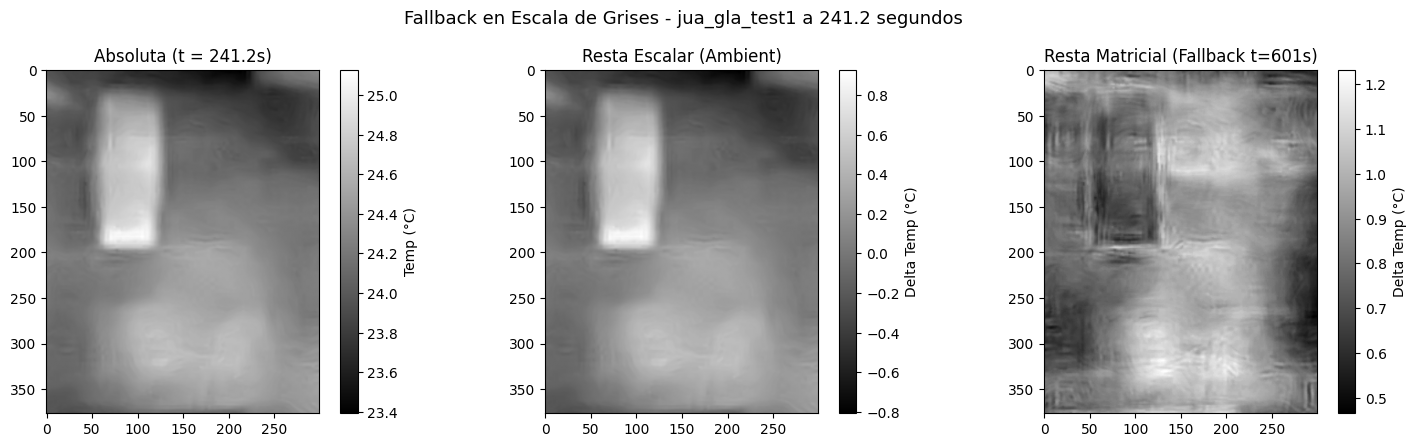

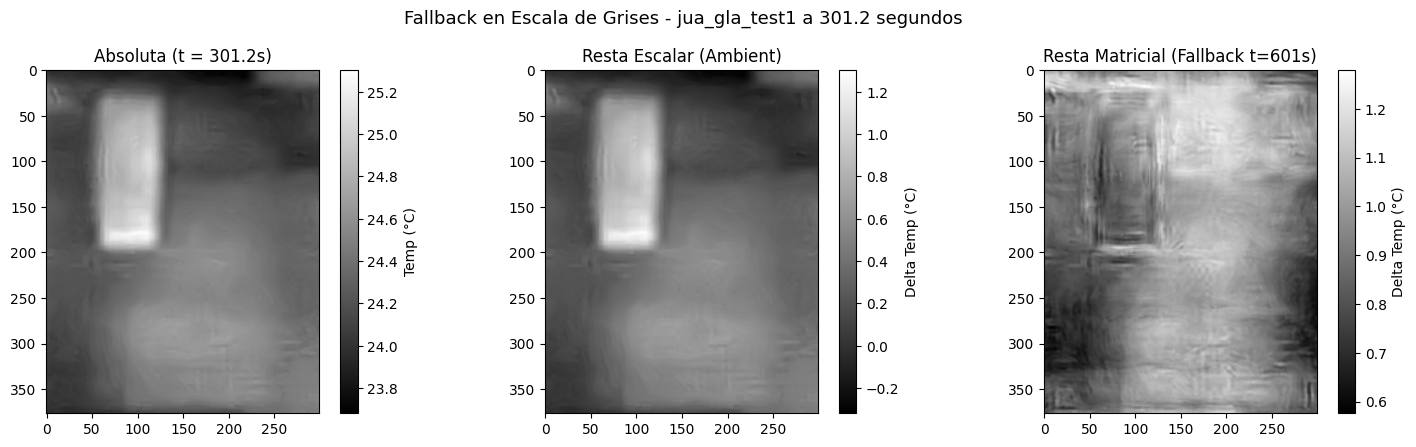

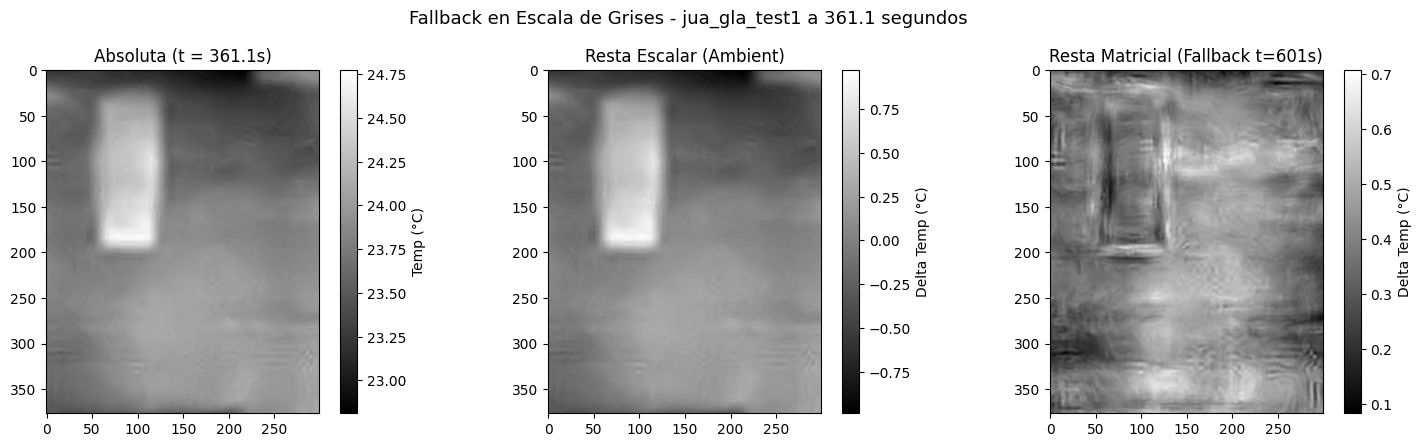

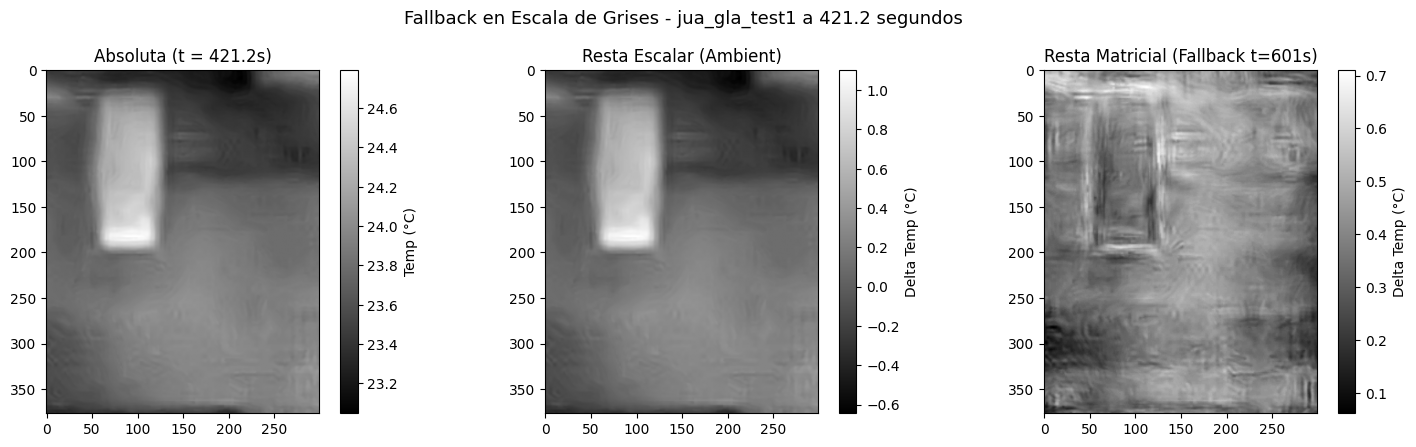

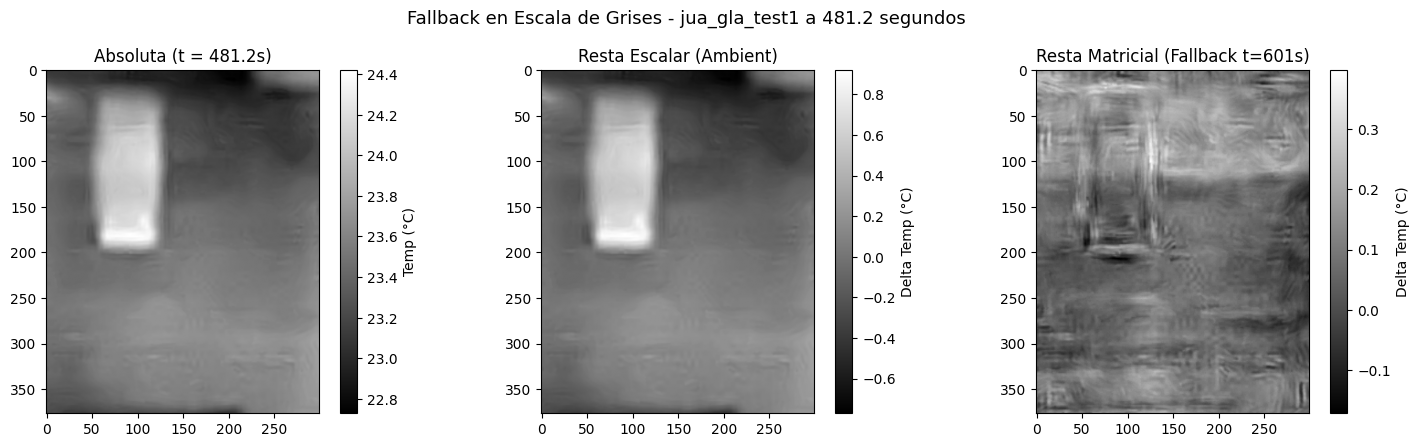

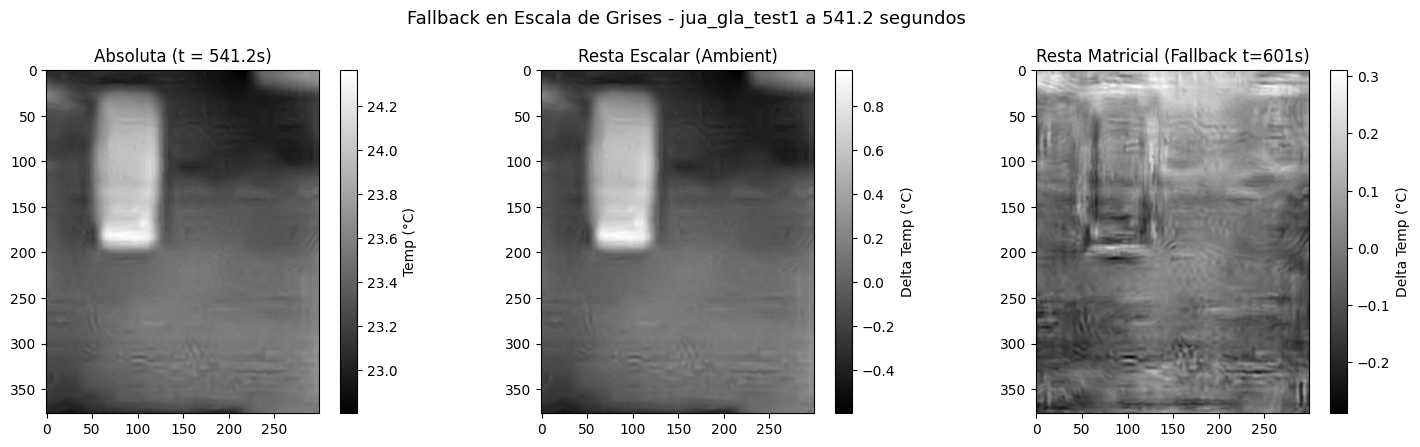

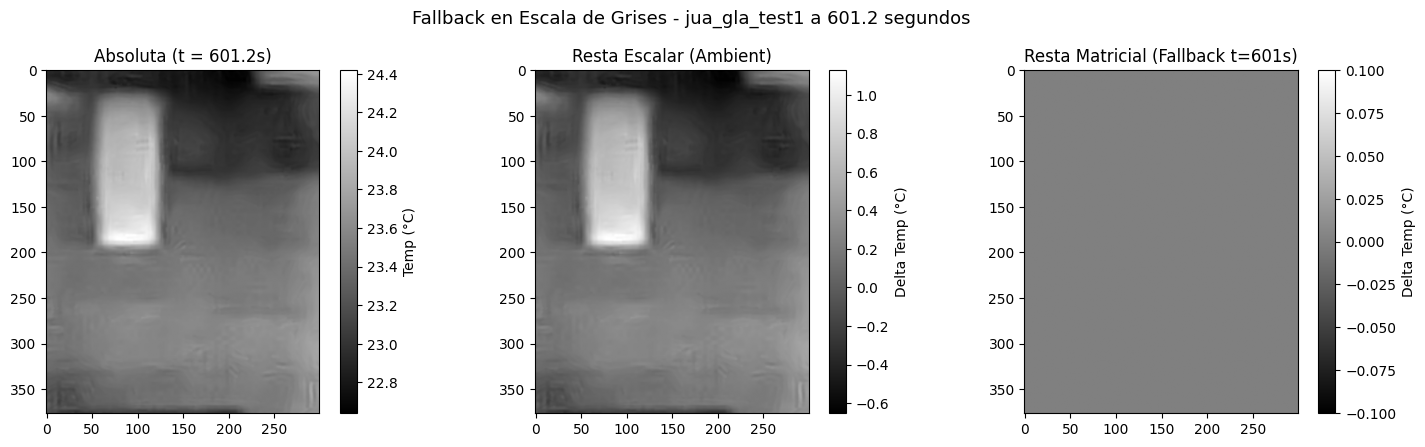

In [10]:
# Filtramos para jua_gla_test1
seq_glass_df = jd_glass[jd_glass["sequence_id"] == "jua_gla_test1"].sort_values("t_seconds")

# Usar el último fotograma como baseline
last_row = seq_glass_df.iloc[-1]
T_material_fallback = np.load(root_dir / last_row["thermal_path"])

target_times_fb = [1.0, 61.0, 121.0, 181.0, 241.0, 301.0, 361.0, 421.0, 481.0, 541.0, 601.0]

for t_target in target_times_fb:
    # Buscar el más cercano a t_target
    row = seq_glass_df.iloc[(seq_glass_df["t_seconds"] - t_target).abs().argsort()[:1]].iloc[0]
    
    path = root_dir / row["thermal_path"]
    T_post = np.load(path)
    
    # Restar escalar vs restar matriz fallback
    T_diff_scalar_fb = T_post - row["ambient_temp_C"]
    T_diff_matrix_fb = T_post - T_material_fallback

    # Graficar comparación en escala de grises
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(T_post, cmap='gray')
    axes[0].set_title(f"Absoluta (t = {row['t_seconds']:.1f}s)")
    fig.colorbar(im0, ax=axes[0], label='Temp (°C)')

    im1 = axes[1].imshow(T_diff_scalar_fb, cmap='gray')
    axes[1].set_title("Resta Escalar (Ambient)")
    fig.colorbar(im1, ax=axes[1], label='Delta Temp (°C)')

    im2 = axes[2].imshow(T_diff_matrix_fb, cmap='gray')
    axes[2].set_title("Resta Matricial (Fallback t=601s)")
    fig.colorbar(im2, ax=axes[2], label='Delta Temp (°C)')

    plt.suptitle(f"Fallback en Escala de Grises - jua_gla_test1 a {row['t_seconds']:.1f} segundos", fontsize=13)
    plt.tight_layout()
    plt.show()

## Conclusiones
1. La visualización en **escala de grises** permite evaluar directamente cómo respondería una CNN tradicional de un solo canal.
2. A medida que avanza el tiempo (ej. más allá del segundo 300), la resta escalar empieza a verse dominada por el ruido térmico absoluto del fondo, mientras que la resta matricial sigue delineando la zona de la huella, aunque su calor remanente sea muy pequeño.
3. Tanto en **madera** (`jua_woo_test1` con pre-mano) como en **vidrio** (`jua_gla_test1` sin pre-mano, usando fallback) la resta matricial resalta significativamente mejor la huella térmica en comparación con la sustracción escalar.